# Hedging-risk experiments (nb_dates sensitivity + VaR/CVaR)


In [6]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

REPO_ROOT = Path('.').resolve()
OUTPUT_DRAFT = REPO_ROOT / 'output' / 'metrics_draft'
OUTPUT_SUMMARY = REPO_ROOT / 'output' / 'summary'
OUTPUT_SUMMARY.mkdir(parents=True, exist_ok=True)

def latest_csv(folder: Path) -> Path:
    files = sorted(folder.glob('*.csv'), key=lambda p: p.stat().st_mtime)
    if not files:
        raise FileNotFoundError(f'No CSV files found in: {folder}')
    return files[-1]

RAW_CSVS = "../reports/output/analysis/diploma_minput_BS.csv" 
raw = pd.read_csv(RAW_CSVS)
raw.head()


,algo,model,payoff,drift,volatility,mean,speed,correlation,hurst,nb_stocks,...,duration,time_path_gen,comp_time,delta,gamma,theta,rho,vega,greeks_method,price_upper_bound
0,LSM,BlackScholes,MinPut,0.05,0.2,0.01,2,-0.3,0.75,1,...,2.236537,0.834149,1.402388,-0.408538,0.022959,-2.241014,-30.328737,37.574462,regression,NaN
1,LSM,BlackScholes,MinPut,0.05,0.2,0.01,2,-0.3,0.75,1,...,1.703421,0.548444,1.154977,-0.420600,0.022995,-2.193792,-29.506889,36.691316,regression,NaN
2,LSM,BlackScholes,MinPut,0.05,0.2,0.01,2,-0.3,0.75,1,...,2.144577,0.741770,1.402807,-0.416326,0.023043,-2.224552,-31.260357,37.875645,regression,NaN
3,LSM,BlackScholes,MinPut,0.05,0.2,0.01,2,-0.3,0.75,1,...,2.178222,0.687879,1.490343,-0.425443,0.023389,-2.244890,-31.058838,37.978272,regression,NaN
4,LSM,BlackScholes,MinPut,0.05,0.2,0.01,2,-0.3,0.75,1,...,1.703549,0.608741,1.094808,-0.424528,0.023285,-2.233546,-29.639627,37.155231,regression,NaN


## 1) Pricing summary (mean ± CI) and runtime


In [7]:

# Filter: 1D BS slice (adjust payoff name if needed)
raw['nb_dates'] = raw['nb_dates'].astype(int)
raw['nb_paths'] = raw['nb_paths'].astype(int)
raw['nb_stocks'] = raw['nb_stocks'].astype(int)

data = raw[(raw['model'] == 'BlackScholes') & (raw['nb_stocks'] == 1)].copy()

def summarize_pricing(df: pd.DataFrame) -> pd.DataFrame:
    gcols = ['algo','nb_dates','nb_paths','spot','strike','maturity','drift','volatility']
    out = (df.groupby(gcols, dropna=False)
             .agg(price_mean=('price','mean'),
                  price_std=('price','std'),
                  delta_mean=('delta','mean'),
                  delta_std=('delta','std'),
                  runs=('price','count'),
                  comp_time_mean=('comp_time','mean'),
                  time_path_gen_mean=('time_path_gen','mean'))
             .reset_index())
    out['price_ci95'] = 1.96*out['price_std']/np.sqrt(out['runs'])
    out['delta_ci95'] = 1.96*out['delta_std']/np.sqrt(out['runs'])
    return out.sort_values(['nb_dates','algo']).reset_index(drop=True)

pricing_summary = summarize_pricing(data)
pricing_summary.to_csv(OUTPUT_SUMMARY/'pricing_nbdates_summary.csv', index=False)
pricing_summary


,algo,nb_dates,nb_paths,spot,strike,maturity,drift,volatility,price_mean,price_std,delta_mean,delta_std,runs,comp_time_mean,time_path_gen_mean,price_ci95,delta_ci95
0,LSM,50,20000,100,100,1.0,0.05,0.2,6.056313,0.061291,-0.422046,0.011785,20,1.316654,0.692570,0.026862,0.005165
1,NLSM,50,20000,100,100,1.0,0.05,0.2,6.056182,0.067968,-0.419711,0.011938,20,44.197758,0.571876,0.029788,0.005232
2,RLSM,50,20000,100,100,1.0,0.05,0.2,6.144618,0.056941,-0.424006,0.011280,20,8.667079,0.810765,0.024955,0.004944


In [ ]:

# Plot price vs nb_dates
for algo in sorted(pricing_summary['algo'].unique()):
    sub = pricing_summary[pricing_summary['algo']==algo].sort_values('nb_dates')
    plt.errorbar(sub['nb_dates'], sub['price_mean'], yerr=sub['price_ci95'], marker='o', capsize=3, label=algo)
plt.xlabel('nb_dates (n)')
plt.ylabel('Price (mean ± 95% CI)')
plt.title('Pricing stability vs discretization')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Plot runtime vs nb_dates
for algo in sorted(pricing_summary['algo'].unique()):
    sub = pricing_summary[pricing_summary['algo']==algo].sort_values('nb_dates')
    plt.plot(sub['nb_dates'], sub['comp_time_mean'], marker='o', label=algo)
plt.xlabel('nb_dates (n)')
plt.ylabel('Mean comp_time (seconds)')
plt.title('Compute time vs discretization')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 2) Hedging risk: buy-and-hold Δ0

We simulate fresh GBM paths and compute discounted shortfall

$L=\max_{i=1..n}\frac{g(S_i)-X_i}{e^{rt_i}}, where (X_i=(V_0-\Delta_0S_0)e^{rt_i}+\Delta_0S_i)$.


In [8]:

def simulate_gbm_paths(S0: float, r: float, sigma: float, T: float, n: int, M: int, seed: int = 123) -> np.ndarray:
    rng = np.random.default_rng(seed)
    dt = T / n
    Z = rng.standard_normal(size=(M, n))
    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    logS = np.log(S0) + np.cumsum(increments, axis=1)
    S = np.concatenate([np.full((M, 1), S0), np.exp(logS)], axis=1)  # (M, n+1)
    return S

def payoff_put(S: np.ndarray, K: float) -> np.ndarray:
    return np.maximum(K - S, 0.0)

def compute_L_buy_and_hold(S_paths: np.ndarray, V0: float, delta0: float, r: float, T: float, K: float) -> np.ndarray:
    M, n1 = S_paths.shape
    n = n1 - 1
    dt = T / n
    t = np.arange(n1) * dt
    disc = np.exp(r * t)
    S0 = S_paths[:, 0]
    B0 = V0 - delta0 * S0
    X_t = B0[:, None] * disc[None, :] + delta0 * S_paths
    g_t = payoff_put(S_paths, K)
    shortfall = (g_t - X_t) / disc[None, :]
    return shortfall[:, 1:].max(axis=1)

def var_cvar(samples: np.ndarray, alpha: float = 0.99):
    q = np.quantile(samples, alpha)
    tail = samples[samples >= q]
    cvar = tail.mean() if len(tail) else np.nan
    return q, cvar

M_HEDGE = 50000
ALPHA = 0.99

risk_rows = []
for (algo, n), sub in data.groupby(['algo','nb_dates']):
    pooled = []
    for _, row in sub.iterrows():
        V0 = float(row['price'])
        d0 = float(row['delta']) if not pd.isna(row['delta']) else 0.0
        r = float(row['drift'])
        sigma = float(row['volatility'])
        T = float(row['maturity'])
        S0 = float(row['spot'])
        K = float(row['strike'])
        S_paths = simulate_gbm_paths(S0, r, sigma, T, int(n), M_HEDGE, seed=123)
        pooled.append(compute_L_buy_and_hold(S_paths, V0, d0, r, T, K))
    L = np.concatenate(pooled, axis=0)
    VaR, CVaR = var_cvar(L, alpha=ALPHA)
    risk_rows.append({'algo':algo,'nb_dates':int(n),'VaR':VaR,'CVaR':CVaR,'L_mean':float(L.mean()),'L_std':float(L.std()),'L_samples':int(L.shape[0])})

risk_df = pd.DataFrame(risk_rows).sort_values(['nb_dates','algo']).reset_index(drop=True)
risk_df.to_csv(OUTPUT_SUMMARY/'hedging_buyhold_nbdates_varcvar.csv', index=False)
risk_df


,algo,nb_dates,VaR,CVaR,L_mean,L_std,L_samples
0,LSM,50,20.385287,24.794141,3.866739,4.958396,1000000
1,NLSM,50,20.239684,24.626199,3.860920,4.939946,1000000
2,RLSM,50,20.382901,24.839928,3.783437,4.973662,1000000


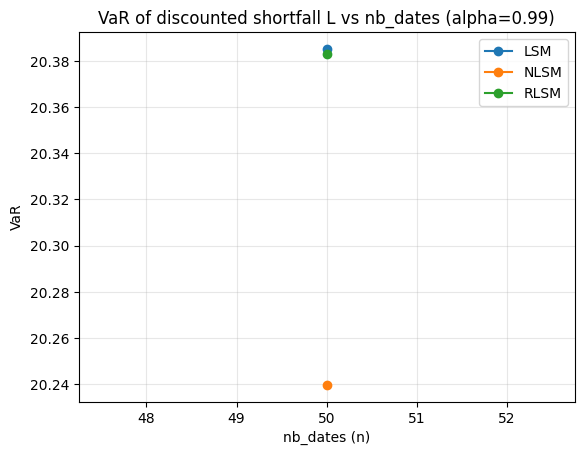

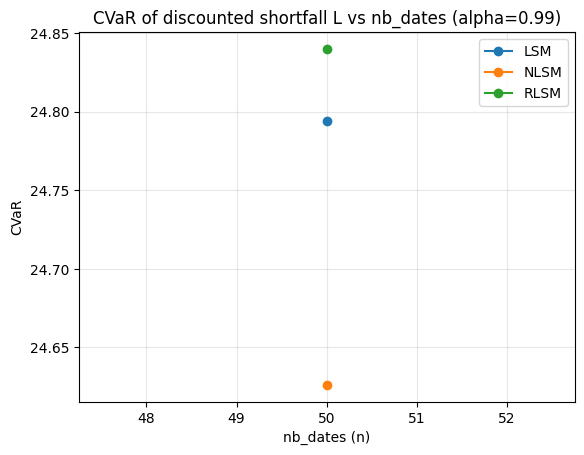

In [9]:

# Plot VaR/CVaR vs nb_dates
for metric in ['VaR','CVaR']:
    for algo in sorted(risk_df['algo'].unique()):
        sub = risk_df[risk_df['algo']==algo].sort_values('nb_dates')
        plt.plot(sub['nb_dates'], sub[metric], marker='o', label=algo)
    plt.xlabel('nb_dates (n)')
    plt.ylabel(metric)
    plt.title(f'{metric} of discounted shortfall L vs nb_dates (alpha={ALPHA})')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


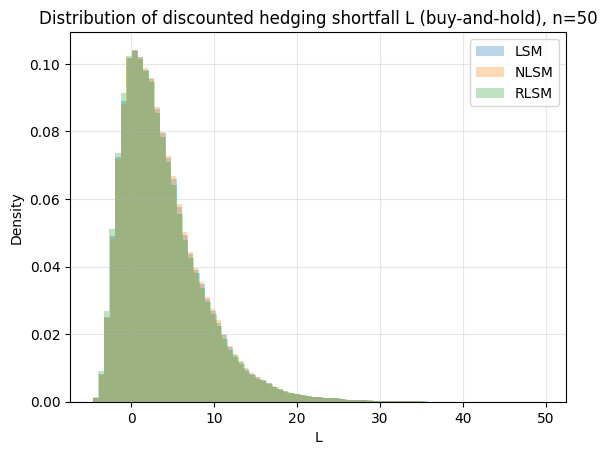

In [10]:

# Distribution plot for a selected n
SELECT_N = 50
subN = data[data['nb_dates']==SELECT_N]
if subN.empty:
    print('No rows for SELECT_N. Available:', sorted(data['nb_dates'].unique()))
else:
    L_by_algo = {}
    for algo, sub in subN.groupby('algo'):
        pooled = []
        for _, row in sub.iterrows():
            V0 = float(row['price'])
            d0 = float(row['delta']) if not pd.isna(row['delta']) else 0.0
            r = float(row['drift']); sigma=float(row['volatility']); T=float(row['maturity'])
            S0=float(row['spot']); K=float(row['strike'])
            S_paths = simulate_gbm_paths(S0, r, sigma, T, SELECT_N, M_HEDGE, seed=123)
            pooled.append(compute_L_buy_and_hold(S_paths, V0, d0, r, T, K))
        L_by_algo[algo] = np.concatenate(pooled, axis=0)

    for algo in sorted(L_by_algo.keys()):
        plt.hist(L_by_algo[algo], bins=80, density=True, alpha=0.3, label=algo)
    plt.xlabel('L')
    plt.ylabel('Density')
    plt.title(f'Distribution of discounted hedging shortfall L (buy-and-hold), n={SELECT_N}')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


## 3) Discrete rebalancing (next step)

To do *rebalance every k steps* (5–10 rebalances), you need **time-dependent** deltas `Δ(t_i,S_i)`.

- Pricing/Δ0 can be obtained via `run_algo.py --compute_greeks`.
- The repository does **not** ship an end-to-end hedging simulator with rebalancing.

Recommended implementation path (no core code changes):
1. In a notebook/script, import the algorithm classes (pricers) directly.
2. Train once: `pricer.price()` to learn continuation models per time.
3. During hedging simulation, query `V(t_i,S_i)` from the trained model and estimate `Δ(t_i,S_i)` via finite difference or autodiff (for neural nets).
4. Apply the self-financing rebalance logic and recompute VaR/CVaR.

If you paste the relevant pricer class you use for NLSM/RLSM, I can write the exact code to extract `V(t_i,S_i)` and compute `Δ(t_i,S_i)` without editing the repo.
